In [8]:
import requests
from textblob import TextBlob
import imageio
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import numpy as np

## Word Frequency Bar Chart and Word Cloud from Shakespeare’sHamlet

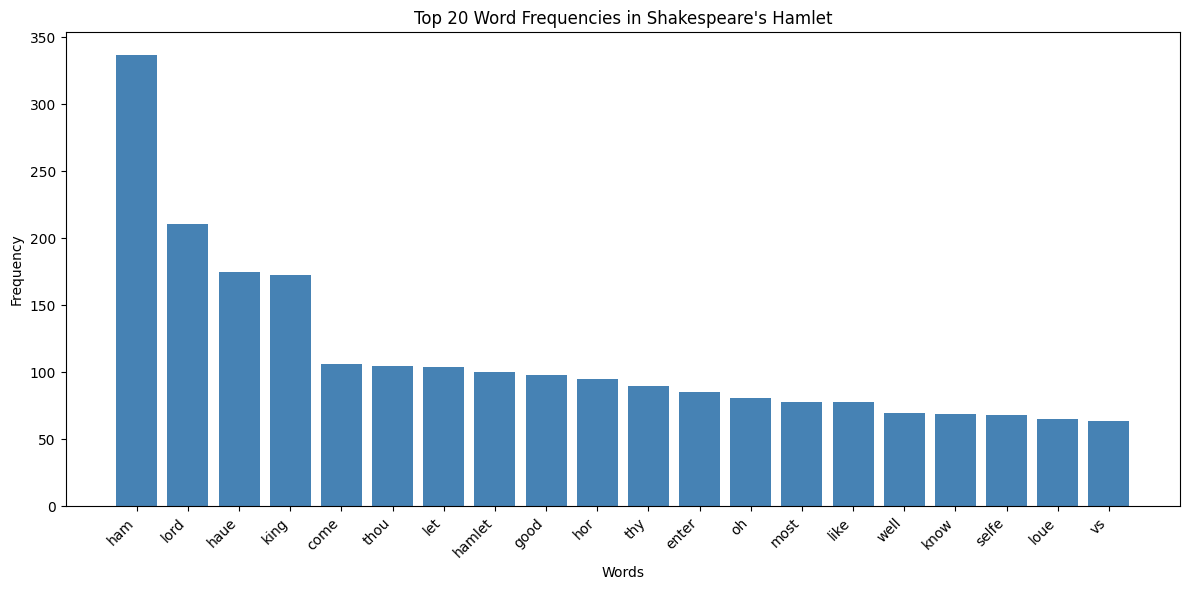

In [12]:
# Word Frequency Bar Chart
target_url = 'https://www.gutenberg.org/files/2265/2265-0.txt'
response = requests.get(target_url)
data = response.text
blob = TextBlob(data)

stop_words = {'the', 'and', 'of', 'to', 'a', 'in', 'i', 'is', 'it', 'that',
              'my', 'with', 'not', 'his', 'this', 'for', 'but', 'you', 'be',
              'he', 'as', 'do', 'at', 'or', 'by', 'so', 'if', 'me', 'her',
              'no', 'we', 'on', 'what', 'have', 'him', 'are', 'shall', 'will',
              'our', 'your', 'from', 'all', 'an', 'was', 'them', 'they', 'which',
              'who', 'their', 'more', 'some', 'than', 'may', 'upon', 'its',
              'would', 'has', 'had', 'how', 'when', 'can', 'did', 'were', 'been',
              'am', 'us', 'she', 'then', 'such', 'there', 'these', 'those', 'too',
              'very', 'should', 'could', 'might', 'must', 'now', 'about', 'into',
              'out', 'up', 'one', 'own', 'only', 'other', 'any', 'each', 'every'}

word_counts = {}
for word in blob.words:
    w = word.lower()
    if w.isalpha() and len(w) > 1 and w not in stop_words:
        word_counts[w] = word_counts.get(w, 0) + 1

sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)[:20]
words, counts = zip(*sorted_words)

plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='steelblue')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.title("Top 20 Word Frequencies in Shakespeare's Hamlet")
plt.tight_layout()
plt.show()

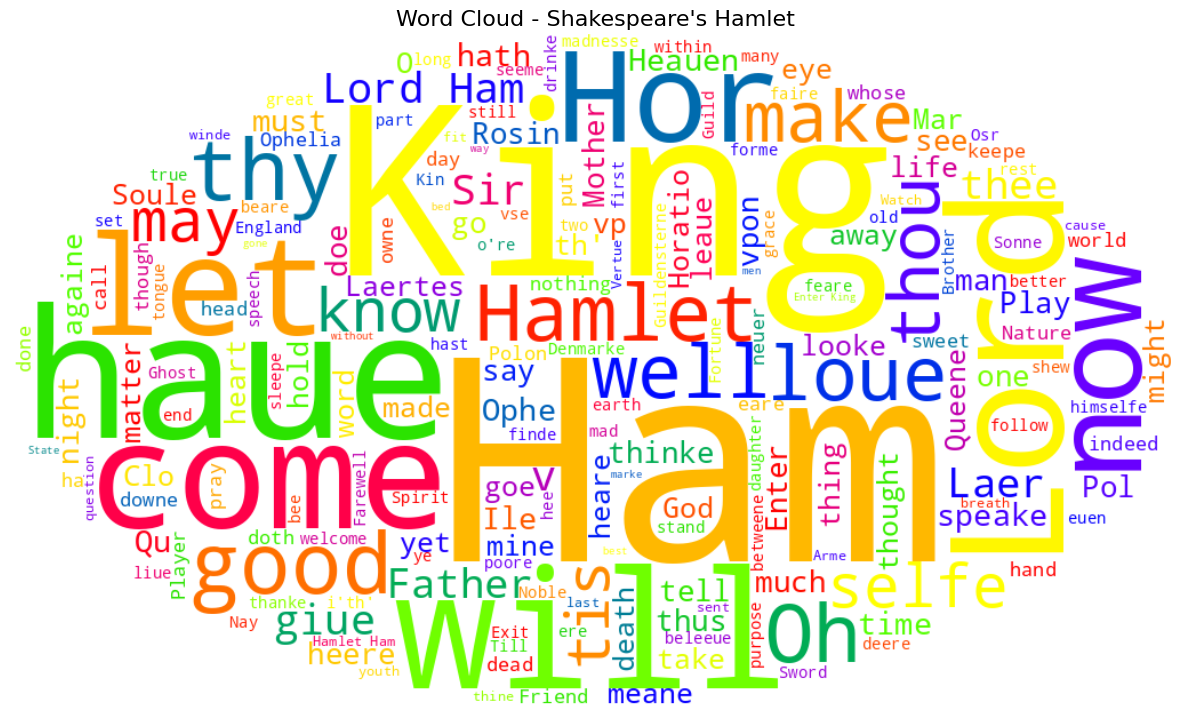

In [25]:
# Word Cloud from Shakespeare's Hamlet
image_file = "https://media.cheggcdn.com/media/216/21621ee5-e80f-47f3-9145-513f2229b390/phploeBuh.png"
mask_image = imageio.v3.imread(image_file)

wordcloud = WordCloud(
    width=800,
    height=400,
    max_words=200,
    colormap='prism',
    mask=mask_image,
    background_color='white'
)
wordcloud.generate(data)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Shakespeare's Hamlet", fontsize=16)
plt.tight_layout()
plt.show()

wordcloud.to_file("hamlet_wordcloud.png")